In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import tools

### get data

In [2]:
dataset = sklearn.datasets.load_iris()

feature_names = dataset.feature_names
label_names = dataset.target_names

features = dataset.data
labels = dataset.target


setosas = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 0])
versicolors = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 1])
virginicas = np.array([features[i] for i in range(features.shape[0]) if labels[i] == 2])
print(feature_names)
print(label_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


### plot graphs

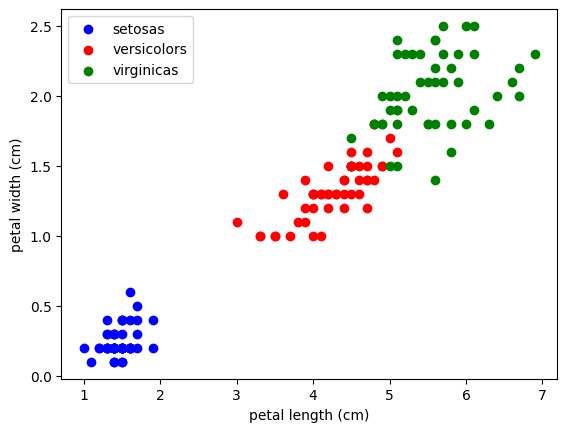

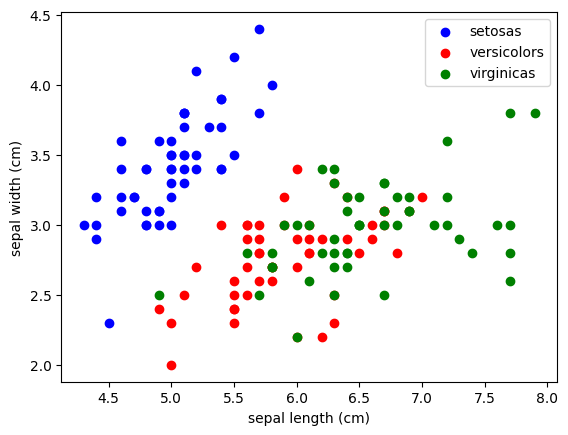

In [3]:
def scatter2features(i, j, feature_names):
    plt.scatter(setosas[:, i], setosas[:, j],
                color='blue',
                label='setosas')
    plt.scatter(versicolors[:, i], versicolors[:, j],
                color='red',
                label='versicolors')
    plt.scatter(virginicas[:, i], virginicas[:, j],
                color='green',
                label='virginicas')
    plt.xlabel(feature_names[i])
    plt.ylabel(feature_names[j])
    plt.legend()
    

scatter2features(2, 3, feature_names)
plt.figure()
scatter2features(0, 1, feature_names)


### k nearest neighbours from point (5.4, 3.7, 3, 2)
Remember, the function calculates distance using all 4 coordinates.
Individual 2D scatter plots may be misleading.

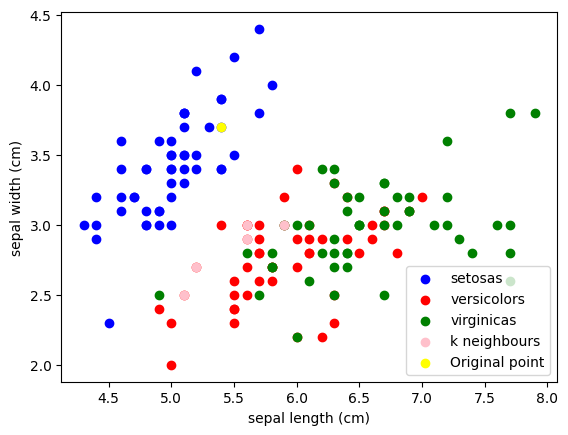

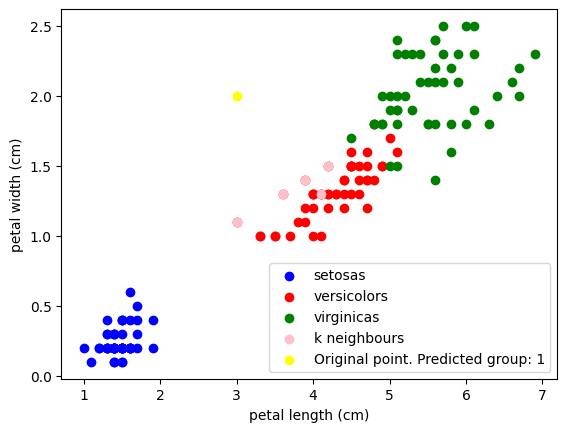

In [4]:
k = 5
point = np.array([5.4, 3.7, 3, 2])
k_neighbours = tools.find_k_nearest_neighbours(k, point, features, labels)
k_neighbour_cords = np.array([neighbour[0] for neighbour in k_neighbours])
predicted_group = tools.predict(k, point, features, labels)


scatter2features(0, 1, feature_names)
plt.scatter(k_neighbour_cords[:, 0], k_neighbour_cords[:, 1],
            label = 'k neighbours',
            color = 'pink')
plt.scatter(point[0], point[1],
            label = 'Original point',
            color = 'yellow')
plt.legend()


plt.figure()
scatter2features(2, 3, feature_names)
plt.scatter(k_neighbour_cords[:, 2], k_neighbour_cords[:, 3],
            label = 'k neighbours',
            color = 'pink')
plt.scatter(point[2], point[3],
            label = 'Original point. Predicted group: ' + str(predicted_group),
            color = 'yellow')
plt.legend()

# Find best k
To find best possible number k, we divide the data into n batches and look how good
the predictions are with different values of k from 0 to n-1

1. Shuffle the data

In [5]:
features_shuffled, labels_shuffled = tools.shuffle_data(features, labels)

2. Divide the data into train and test blocks

In [6]:
division_index = 120

features_train = features_shuffled[:division_index]
labels_train = labels_shuffled[:division_index]

features_test = features_shuffled[division_index:]
labels_test = labels_shuffled[division_index:]

3. Find which k has the best accuracy rate

In [9]:
number_of_batches = 5

k_range = 10
accuracies = [0 for i in range(k_range)]

for k in range(1, k_range + 1):
    
    for i in range(features_test.shape[0]):
        cords = features_test[i]
        label = labels_test[i]
        
        success_num = 0
        # count all successes in a batch    
        prediction = tools.predict(k, cords, features_train, labels_train)
        if (prediction == label): success_num += 1
    
    accuracy = success_num / features_test.shape[0]
    accuracies[k-1] = accuracy

print(accuracies)
    


[0.03333333333333333, 0.0, 0.03333333333333333, 0.03333333333333333, 0.03333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0]
